# Phase 3: Supervised Learning for False Positive Reduction
# Task 3.3: Random Forest Baseline

Build a supervised flow-level classifier that separates benign and attack flows.

This notebook establishes the first Phase 3 baseline. It uses the fixed train, validation, and test splits created during flow preprocessing.

## Setup and load the fixed flow splits

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve
)

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.data.flow_preprocessing import ATTACK_COL, BINARY_COL, FLOW_KEY_COL, TARGET_COL, build_flow_preprocessor

DATA_FOLDER = "phase3"
DATA_DIR = PROJECT_ROOT / "data" / "processed" / DATA_FOLDER
META_PATH = DATA_DIR / "flow_split_metadata.json"

with open(META_PATH, "r") as f:
    metadata = json.load(f)

train_df = pd.read_csv(DATA_DIR / "flow_train.csv", low_memory=False)
validation_df = pd.read_csv(DATA_DIR / "flow_validation.csv", low_memory=False)
test_df = pd.read_csv(DATA_DIR / "flow_test.csv", low_memory=False)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)
metadata

Train shape: (89593, 89)
Validation shape: (19199, 89)
Test shape: (19199, 89)


{'input_path': 'data/samples/flow_sample_seed1.csv',
 'seed': 1,
 'validation_size': 0.15,
 'test_size': 0.15,
 'raw_rows': 127991,
 'clean_rows': 127991,
 'feature_count': 80,
 'feature_columns': ['Src Port',
  'Dst Port',
  'Protocol',
  'Flow Duration',
  'Total Fwd Packet',
  'Total Bwd packets',
  'Total Length of Fwd Packet',
  'Total Length of Bwd Packet',
  'Fwd IAT Total',
  'Bwd IAT Total',
  'Fwd PSH Flags',
  'Bwd PSH Flags',
  'Fwd URG Flags',
  'Bwd URG Flags',
  'Fwd Header Length',
  'Bwd Header Length',
  'FIN Flag Count',
  'SYN Flag Count',
  'RST Flag Count',
  'PSH Flag Count',
  'ACK Flag Count',
  'URG Flag Count',
  'CWR Flag Count',
  'ECE Flag Count',
  'Subflow Fwd Packets',
  'Subflow Fwd Bytes',
  'Subflow Bwd Packets',
  'Subflow Bwd Bytes',
  'Fwd Act Data Pkts',
  'Fwd Packet Length Max',
  'Bwd Packet Length Max',
  'Flow IAT Max',
  'Fwd IAT Max',
  'Bwd IAT Max',
  'Packet Length Max',
  'Active Max',
  'Idle Max',
  'Fwd Packet Length Min',
  'Bwd Pa

### Verify the class distribution and split integrity

In [2]:
for name, current_df in [("Train", train_df), ("Validation", validation_df), ("Test", test_df)]:
    print(f"{name} binary counts")
    print(current_df[BINARY_COL].value_counts())
    print()

train_keys = set(train_df[FLOW_KEY_COL])
validation_keys = set(validation_df[FLOW_KEY_COL])
test_keys = set(test_df[FLOW_KEY_COL])

print("Flow-key overlap")
print("Train and validation:", len(train_keys & validation_keys))
print("Train and test:", len(train_keys & test_keys))
print("Validation and test:", len(validation_keys & test_keys))

Train binary counts
binary_label
benign    86064
attack     3529
Name: count, dtype: int64

Validation binary counts
binary_label
benign    18443
attack      756
Name: count, dtype: int64

Test binary counts
binary_label
benign    18443
attack      756
Name: count, dtype: int64

Flow-key overlap
Train and validation: 0
Train and test: 0
Validation and test: 0


## Random Forest feature preparation

The model uses the 80 numeric flow-behaviour features recorded in the split metadata. Labels, flow identifiers, IP addresses, timestamps, and source-file information are excluded.

Random Forest does not require feature scaling. The preprocessing pipeline therefore only:

- replaces remaining missing values with the training median;
- adds missing-value indicators where needed;
- removes constant features.

The preprocessing pipeline is fitted using the training set only.

In [3]:
feature_cols = metadata["feature_columns"]
missing_features = [col for col in feature_cols if col not in train_df.columns]

if missing_features:
    raise ValueError(f"Missing model features: {missing_features}")

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL].to_numpy()

X_validation = validation_df[feature_cols]
y_validation = validation_df[TARGET_COL].to_numpy()

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL].to_numpy()

print("Input features:", len(feature_cols))
print("Training missing values:", int(X_train.isna().sum().sum()))
print("Validation missing values:", int(X_validation.isna().sum().sum()))
print("Test missing values:", int(X_test.isna().sum().sum()))

Input features: 80
Training missing values: 136
Validation missing values: 16
Test missing values: 20


## Train the Random Forest baseline

This baseline uses 300 trees and the square root of the available features at each split. `balanced_subsample` recalculates class weights for each bootstrap sample, helping the model learn from the minority attack class without duplicating observations.

The probability threshold remains at the standard value of 0.5. Hyperparameter and threshold tuning will be performed only after the baseline result is recorded.

In [4]:
RANDOM_STATE = 1
BASELINE_THRESHOLD = 0.50

preprocessor = build_flow_preprocessor(scale=False)
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", random_forest)
])

start_train = time.perf_counter()
rf_pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - start_train

print(f"Training time: {train_time:.2f} seconds")
print("Processed features:", rf_pipeline.named_steps["preprocessor"].named_steps["remove_constant"].get_support().sum())

Training time: 6.72 seconds
Processed features: 77


## Baseline evaluation

In [5]:
def evaluate_binary_classifier(name, y_true, scores, threshold, prediction_time):
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    result = {
        "dataset": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        "alerts": int(y_pred.sum()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "prediction_time_sec": prediction_time
    }

    return result, y_pred

start_validation = time.perf_counter()
validation_scores = rf_pipeline.predict_proba(X_validation)[:, 1]
validation_prediction_time = time.perf_counter() - start_validation

start_test = time.perf_counter()
test_scores = rf_pipeline.predict_proba(X_test)[:, 1]
test_prediction_time = time.perf_counter() - start_test

validation_metrics, validation_pred = evaluate_binary_classifier(
    "Validation", y_validation, validation_scores, BASELINE_THRESHOLD, validation_prediction_time
)
test_metrics, test_pred = evaluate_binary_classifier(
    "Test", y_test, test_scores, BASELINE_THRESHOLD, test_prediction_time
)

metrics_df = pd.DataFrame([validation_metrics, test_metrics])
display(metrics_df.round(4))

,dataset,threshold,accuracy,precision,recall,f1,specificity,fpr,fnr,roc_auc,pr_auc,alerts,tn,fp,fn,tp,prediction_time_sec
0,Validation,0.5,0.9868,0.9037,0.7447,0.8165,0.9967,0.0033,0.2553,0.9540,0.8605,623,18383,60,193,563,0.1949
1,Test,0.5,0.9869,0.9244,0.7275,0.8142,0.9976,0.0024,0.2725,0.9573,0.8501,595,18398,45,206,550,0.0880


### Confusion matrices

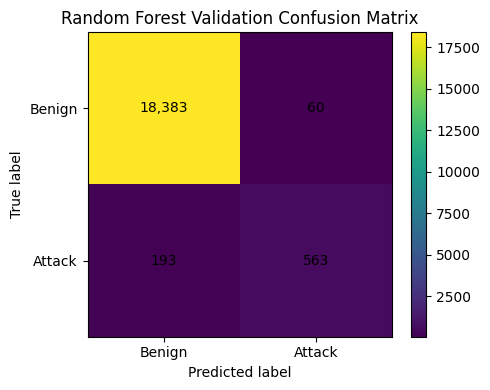

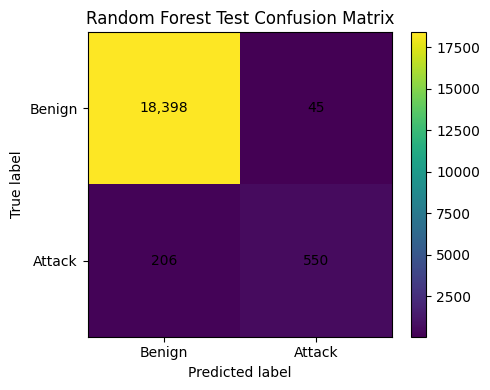

In [6]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Benign", "Attack"])
    plt.yticks([0, 1], ["Benign", "Attack"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_validation, validation_pred, "Random Forest Validation Confusion Matrix")
plot_confusion_matrix(y_test, test_pred, "Random Forest Test Confusion Matrix")

### Test classification report

In [7]:
report = classification_report(
    y_test,
    test_pred,
    target_names=["Benign", "Attack"],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
display(report_df.round(4))

,precision,recall,f1-score,support
Benign,0.9889,0.9976,0.9932,18443.0000
Attack,0.9244,0.7275,0.8142,756.0000
accuracy,0.9869,0.9869,0.9869,0.9869
macro avg,0.9566,0.8625,0.9037,19199.0000
weighted avg,0.9864,0.9869,0.9862,19199.0000


### Results by traffic type

,total,correct,incorrect,correct_rate
attack_type,,,,
Benign,18443,18398,45,99.76
DDoS-HTTP Flood,147,143,4,97.28
DoS-HTTP Flood,153,134,19,87.58
DNS Spoofing,152,72,80,47.37
Brute Force,146,93,53,63.70
XSS,158,108,50,68.35


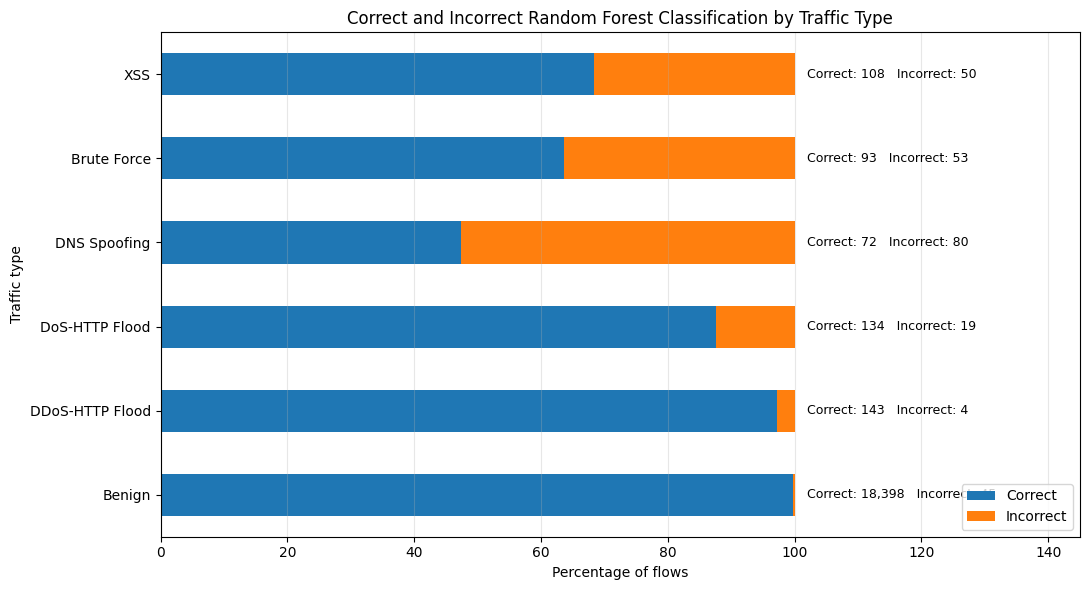

In [8]:
type_results = test_df[[ATTACK_COL]].copy()
type_results["y_true"] = y_test
type_results["y_pred"] = test_pred
type_results["correct"] = type_results["y_true"] == type_results["y_pred"]

result_by_type = type_results.groupby(ATTACK_COL).agg(total=("correct", "size"), correct=("correct", "sum"))
result_by_type["incorrect"] = result_by_type["total"] - result_by_type["correct"]
result_by_type["correct_rate"] = result_by_type["correct"] / result_by_type["total"] * 100
result_by_type["incorrect_rate"] = 100 - result_by_type["correct_rate"]

type_order = ["Benign", "DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]
result_by_type = result_by_type.reindex(type_order).dropna()

display(result_by_type[["total", "correct", "incorrect", "correct_rate"]].round(2))

plot_data = result_by_type[["correct_rate", "incorrect_rate"]]
ax = plot_data.plot(kind="barh", stacked=True, figsize=(11, 6))

for i, (_, row) in enumerate(result_by_type.iterrows()):
    count_text = f'Correct: {int(row["correct"]):,}   Incorrect: {int(row["incorrect"]):,}'
    ax.text(102, i, count_text, va="center", fontsize=9)

ax.set_xlim(0, 145)
ax.set_xlabel("Percentage of flows")
ax.set_ylabel("Traffic type")
ax.set_title("Correct and Incorrect Random Forest Classification by Traffic Type")
ax.legend(["Correct", "Incorrect"], loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### ROC and precision-recall curves

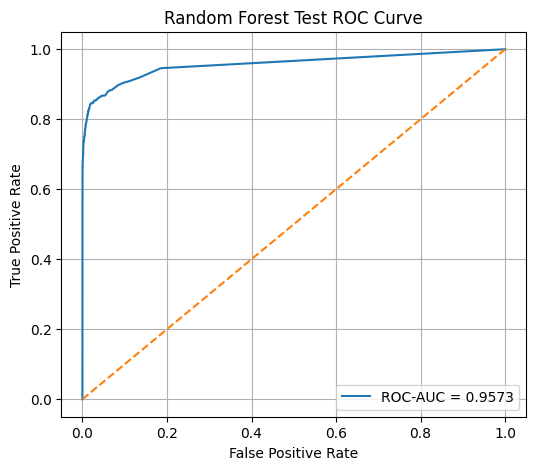

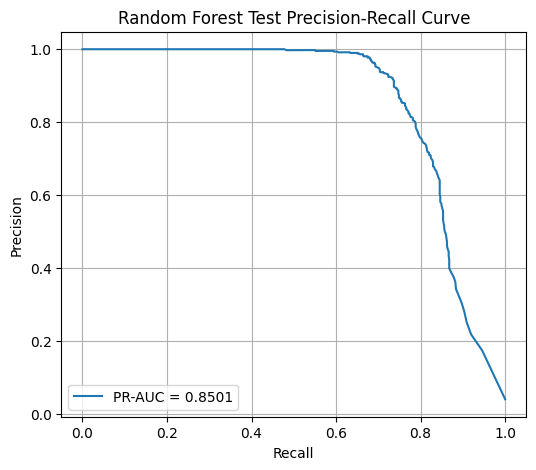

In [9]:
def plot_roc_curve(y_true, scores, title):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_precision_recall_curve(y_true, scores, title):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc_curve(y_test, test_scores, "Random Forest Test ROC Curve")
plot_precision_recall_curve(y_test, test_scores, "Random Forest Test Precision-Recall Curve")

## Feature importance

Random Forest importance measures how much each feature reduces impurity across the trees.

,feature,importance
0,Flow IAT Max,0.054702
1,Flow Bytes/s,0.050436
2,Flow Duration,0.042581
3,Flow Packets/s,0.042422
4,Fwd Packets/s,0.039232
5,Flow IAT Mean,0.038322
6,Src Port,0.037504
7,Bwd Packets/s,0.032041
8,Dst Port,0.029827
9,Flow IAT Min,0.027817


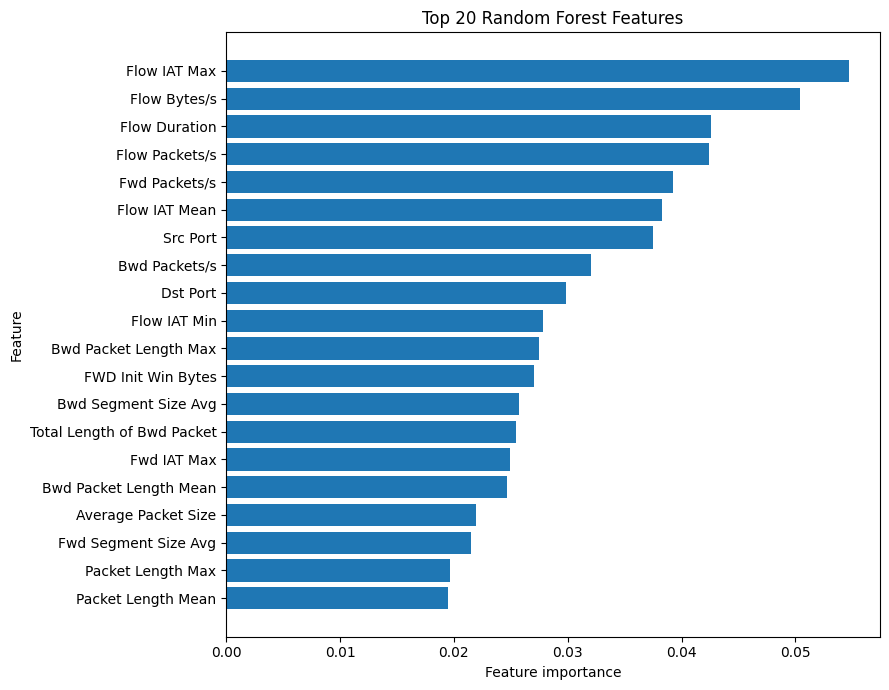

In [10]:
processed_feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out(feature_cols)
feature_importance = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": processed_feature_names,
    "importance": feature_importance
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(importance_df.head(20))

plot_importance = importance_df.head(20).sort_values("importance")
plt.figure(figsize=(9, 7))
plt.barh(plot_importance["feature"], plot_importance["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Features")
plt.tight_layout()
plt.show()

## Save the baseline results

In [11]:
RESULTS_DIR = PROJECT_ROOT / "reports" / "phase3"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

metrics_output = metrics_df.copy()
metrics_output.insert(0, "model", "Random Forest Baseline")
metrics_output["training_time_sec"] = train_time
metrics_output.to_csv(RESULTS_DIR / "random_forest_baseline_metrics.csv", index=False)

importance_df.to_csv(RESULTS_DIR / "random_forest_baseline_feature_importance.csv", index=False)

prediction_cols = [FLOW_KEY_COL, ATTACK_COL, BINARY_COL, TARGET_COL]
test_predictions = test_df[prediction_cols].copy()
test_predictions["attack_probability"] = test_scores
test_predictions["prediction"] = test_pred
test_predictions.to_csv(RESULTS_DIR / "random_forest_baseline_test_predictions.csv", index=False)

print("Saved baseline results to:", RESULTS_DIR)

Saved baseline results to: /Users/yuanmingwang/Documents/doc/uvic/Summer 2026/ECE 597 Capstone Project/multi-stage-iot-ids/reports/phase3


## Final baseline summary

In [12]:
test_row = metrics_df.loc[metrics_df["dataset"] == "Test"].iloc[0]

print("Final Random Forest baseline test results")
print("-----------------------------------------")
print(f"Accuracy: {test_row['accuracy']:.4f}")
print(f"Precision: {test_row['precision']:.4f}")
print(f"Recall: {test_row['recall']:.4f}")
print(f"F1-score: {test_row['f1']:.4f}")
print(f"ROC-AUC: {test_row['roc_auc']:.4f}")
print(f"PR-AUC: {test_row['pr_auc']:.4f}")
print(f"FPR: {test_row['fpr']:.4f}")
print(f"FNR: {test_row['fnr']:.4f}")
print(f"Training time: {train_time:.2f} seconds")
print(f"Test prediction time: {test_prediction_time:.2f} seconds")

print()
print("Correct classification rate by traffic type")
for attack_type in type_order:
    row = result_by_type.loc[attack_type]
    print(f"{attack_type}: {row['correct_rate']:.2f}%")

Final Random Forest baseline test results
-----------------------------------------
Accuracy: 0.9869
Precision: 0.9244
Recall: 0.7275
F1-score: 0.8142
ROC-AUC: 0.9573
PR-AUC: 0.8501
FPR: 0.0024
FNR: 0.2725
Training time: 6.72 seconds
Test prediction time: 0.09 seconds

Correct classification rate by traffic type
Benign: 99.76%
DDoS-HTTP Flood: 97.28%
DoS-HTTP Flood: 87.58%
DNS Spoofing: 47.37%
Brute Force: 63.70%
XSS: 68.35%
